In [24]:
import requests
import pandas as pd
import os
import requests
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [25]:
def get_ciso_EIA_data(start_date, end_date):
    load_dotenv()

    API_KEY = os.getenv("EIA_API_KEY")

    BASE_URL = "https://api.eia.gov/v2"

    DATA_URL = (
        f"{BASE_URL}/electricity/rto/"
        "region-data/data/"
    )

    params = {
        "api_key": API_KEY,
        "frequency": "hourly",
        "data[0]": "value",

        # California ISO
        "facets[respondent][]": "CISO",

        # Actual demand
        "facets[type][]": "D",

        "start": start_date,
        "end": end_date,

        "sort[0][column]": "period",
        "sort[0][direction]": "asc",

        "offset": 0,
        "length": 5000
    }

    response = requests.get(
        DATA_URL,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    result = response.json()
    print("Total rows:", result["response"]["total"])

    return result

In [26]:
def formating_ciso_data(df):
    df["period"] = pd.to_datetime(
            df["period"],
            utc=True
        )
    
    df["value"] = pd.to_numeric(
        df["value"],
            errors="coerce"
        )
    
    df = (
        df
        .sort_values("period")
        .reset_index(drop=True)
    )
    
    df["target_demand_1h"] = (
        df["value"].shift(-1)
    )

    return df

In [27]:
def get_ciso_df(start_year, end_year):
    full_df = pd.DataFrame()
    for i in range (start_year, end_year+1):
        year = 2000 + i
        # start_date = f"{year}-01-01T00"
        # end_date = f"{year}-12-31T23"

        result_01_07 = get_ciso_EIA_data(start_date=f"{year}-01-01T00", end_date=f"{year}-07-28T07")
        result_07_12 = get_ciso_EIA_data(start_date=f"{year}-07-28T08", end_date=f"{year}-12-31T13")
        df1 = pd.DataFrame(result_01_07["response"]["data"])
        df2 = pd.DataFrame(result_07_12["response"]["data"])
        df3 = pd.concat([df1, df2], ignore_index=True, axis=0)
        full_df = pd.concat([full_df, df3], ignore_index=True, axis=0)

    return full_df

In [28]:
full_df = get_ciso_df(19, 26)
full_df = formating_ciso_data(full_df)
print(f"start period: {full_df['period'].iloc[0]}")
print(f"end period: {full_df['period'].iloc[-1]}")
full_df

Total rows: 5000
Total rows: 3749
Total rows: 5024
Total rows: 3750
Total rows: 5000
Total rows: 3749
Total rows: 5000
Total rows: 3750
Total rows: 5000
Total rows: 3750
Total rows: 5024
Total rows: 3750
Total rows: 5000
Total rows: 3750
Total rows: 5000
Total rows: 1230
start period: 2019-01-01 00:00:00+00:00
end period: 2026-09-17 13:00:00+00:00


,period,respondent,respondent-name,type,type-name,value,value-units,target_demand_1h
0,2019-01-01 00:00:00+00:00,CISO,California Independent System Operator,D,Demand,23216.0,megawatthours,24947.0
1,2019-01-01 01:00:00+00:00,CISO,California Independent System Operator,D,Demand,24947.0,megawatthours,27654.0
2,2019-01-01 02:00:00+00:00,CISO,California Independent System Operator,D,Demand,27654.0,megawatthours,27676.0
3,2019-01-01 03:00:00+00:00,CISO,California Independent System Operator,D,Demand,27676.0,megawatthours,26853.0
4,2019-01-01 04:00:00+00:00,CISO,California Independent System Operator,D,Demand,26853.0,megawatthours,25940.0
...,...,...,...,...,...,...,...,...
67473,2026-09-17 09:00:00+00:00,CISO,California Independent System Operator,D,Demand,24792.0,megawatthours,24344.0
67474,2026-09-17 10:00:00+00:00,CISO,California Independent System Operator,D,Demand,24344.0,megawatthours,23640.0
67475,2026-09-17 11:00:00+00:00,CISO,California Independent System Operator,D,Demand,23640.0,megawatthours,23652.0
67476,2026-09-17 12:00:00+00:00,CISO,California Independent System Operator,D,Demand,23652.0,megawatthours,24779.0


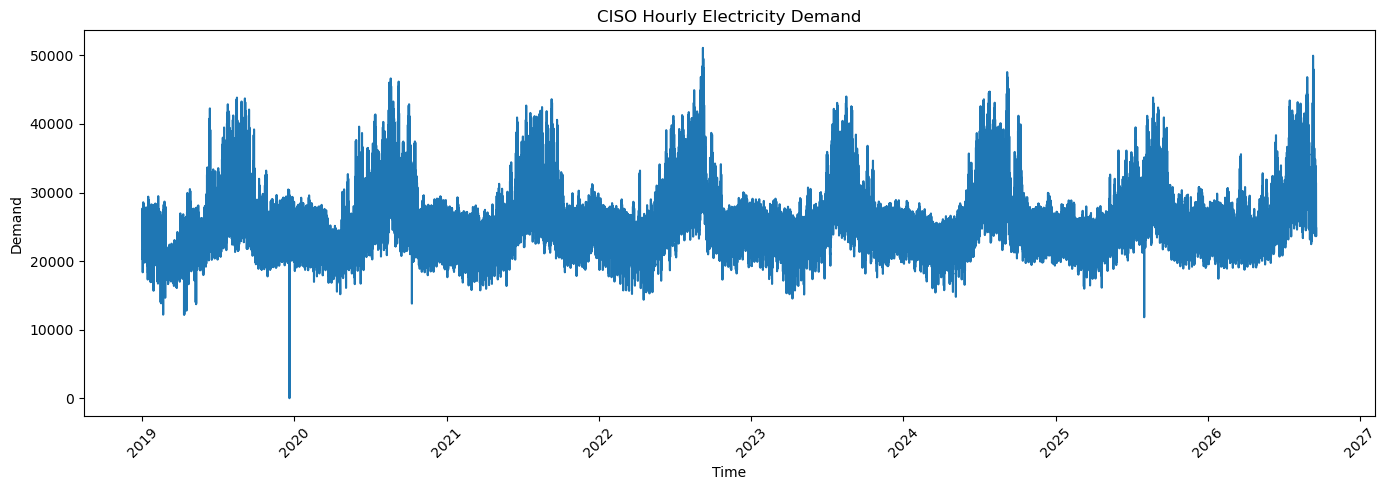

In [29]:
plt.figure(figsize=(14, 5))

plt.plot(
    full_df["period"],
    full_df["value"]
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("CISO Hourly Electricity Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67478 entries, 0 to 67477
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   period            67478 non-null  datetime64[ns, UTC]
 1   respondent        67478 non-null  object             
 2   respondent-name   67478 non-null  object             
 3   type              67478 non-null  object             
 4   type-name         67478 non-null  object             
 5   value             67456 non-null  float64            
 6   value-units       67478 non-null  object             
 7   target_demand_1h  67455 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), object(5)
memory usage: 4.1+ MB


In [32]:
full_df.duplicated().sum()

np.int64(0)

In [33]:
full_df.isna().sum()

period               0
respondent           0
respondent-name      0
type                 0
type-name            0
value               22
value-units          0
target_demand_1h    23
dtype: int64